target :Order Profit Per Order

# Task 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()


In [2]:
!pip install py7zr

import py7zr

archive_path = '/content/DataCoSupplyChainDataset_Cleaned.7z'  # updated file name
extract_path = '/content/DataCoSupplyChainDataset_Cleaned'      # folder to extract files

with py7zr.SevenZipFile(archive_path, mode='r') as z:
    z.extractall(path=extract_path)

print("Extraction completed!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.0/97.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.7/51.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.7/142.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.6/413.6 kB 22.8 MB/s eta 0:00:00
Extraction completed!


# Task 2: Load and Explore the Cleaned Dataset

In [36]:
# Load the processed dataset produced by Notebook 01

csv_path = '/content/DataCoSupplyChainDataset_Cleaned/DataCoSupplyChainDataset_Cleaned.csv'
df = pd.read_csv(csv_path, encoding='latin1')      # read the single cleaned CSV produced earlier
print(f"[INFO] Loaded processed dataset → {df.shape[0]:,} rows, {df.shape[1]} cols")  # print row/column counts

# Preview (first & last rows)
display(df.head())
display(df.tail())

# Data types / memory
print("\n===== INFO =====")
df.info()

# Quick numeric summary
print("\n===== DESCRIBE (numeric) =====")
display(df.describe().T.head(20))

# Quick duplicates & missing check (should be none after Notebook 01)
print(f"\nDuplicate rows: {df.duplicated().sum()}")
missing_pct = (df.isna().mean()*100).round(2)
print("Any missing after preprocessing? ->", (missing_pct > 0).any())


[INFO] Loaded processed dataset → 180,519 rows, 168 cols


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Department Id,Latitude,Longitude,Order Item Cardprod Id,Order Item Discount,...,Order Status_COMPLETE,Order Status_ON_HOLD,Order Status_PAYMENT_REVIEW,Order Status_PENDING,Order Status_PENDING_PAYMENT,Order Status_PROCESSING,Order Status_SUSPECTED_FRAUD,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class
0,3,4,91.250000,314.640015,0,2,18.251453,-66.037056,1360,13.110000,...,True,False,False,False,False,False,False,False,False,True
1,5,4,-249.089996,311.359985,1,2,18.279451,-66.037064,1360,16.389999,...,False,False,False,True,False,False,False,False,False,True
2,4,4,-247.779999,309.720001,0,2,37.292233,-121.881279,1360,18.030001,...,False,False,False,False,False,False,False,False,False,True
3,3,4,22.860001,304.809998,0,2,34.125946,-118.291016,1360,22.940001,...,True,False,False,False,False,False,False,False,False,True
4,2,4,134.210007,298.250000,0,2,18.253769,-66.037048,1360,29.500000,...,False,False,False,False,True,False,False,False,False,True


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Department Id,Latitude,Longitude,Order Item Cardprod Id,Order Item Discount,...,Order Status_COMPLETE,Order Status_ON_HOLD,Order Status_PAYMENT_REVIEW,Order Status_PENDING,Order Status_PENDING_PAYMENT,Order Status_PROCESSING,Order Status_SUSPECTED_FRAUD,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class
180514,4,4,40.000000,399.980011,0,7,40.640930,-73.942711,1004,0.0,...,False,False,False,False,False,False,False,False,False,True
180515,3,2,-613.770019,395.980011,1,7,35.362545,-119.018700,1004,4.0,...,True,False,False,False,False,False,False,False,True,False
180516,5,4,141.110001,391.980011,1,7,41.629959,-72.967155,1004,8.0,...,False,False,False,True,False,False,False,False,False,True
180517,3,4,186.229996,387.980011,0,7,18.213350,-66.370575,1004,12.0,...,False,False,False,False,True,False,False,False,False,True
180518,4,4,168.949997,383.980011,0,7,18.290380,-66.370613,1004,16.0,...,False,False,False,False,True,False,False,False,False,True



===== INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Columns: 168 entries, Days for shipping (real) to Shipping Mode_Standard Class
dtypes: bool(150), float64(12), int64(6)
memory usage: 50.6 MB

===== DESCRIBE (numeric) =====


,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933
Longitude,180519.0,-84.915675,21.433241,-158.025986,-98.446312,-76.847908,-66.370583,115.263077
Order Item Cardprod Id,180519.0,692.509764,336.446807,19.000000,403.000000,627.000000,1004.000000,1363.000000
Order Item Discount,180519.0,20.664741,21.800901,0.000000,5.400000,14.000000,29.990000,500.000000



Duplicate rows: 0
Any missing after preprocessing? -> False


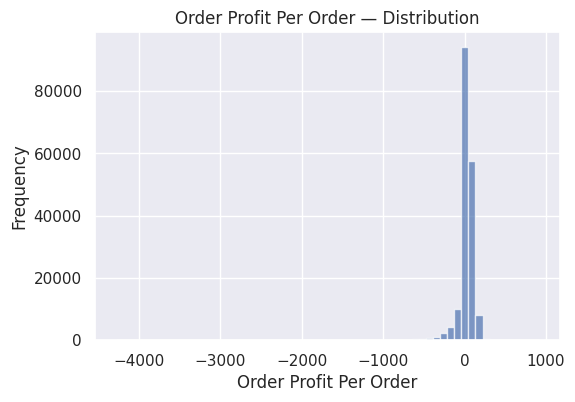

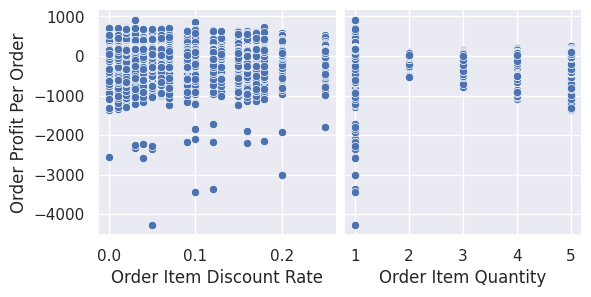

In [37]:
target_col = "Order Profit Per Order"
ax = df[target_col].plot(kind="hist", bins=60, alpha=0.7, figsize=(6,4), title=f"{target_col} — Distribution")
ax.set_xlabel(target_col)

import seaborn as sns
subset_cols = ["Order Item Discount Rate", "Order Item Quantity", target_col]
subset = df[subset_cols].copy()
sns.pairplot(subset, x_vars=["Order Item Discount Rate", "Order Item Quantity"], y_vars=target_col, kind="scatter", height=3)



# Task 3: Select the Regression Target (Order Profit Per Order) & Build X / y

In [42]:
# === Task 3

target_col = "Order Profit Per Order"
y = df[target_col]

# 1) Drop targets and direct/derived financial leaks
base_drop = [
    # targets
    "Late_delivery_risk", "Order Item Total", "Product Price", target_col,
    # direct proxy
    "Benefit per order",
    # financial/derived columns that can reconstruct profit
    "Sales", "Sales per customer",
    "Order Item Product Price", "Order Item Profit Ratio",
    "Order Item Quantity", "Order Item Discount", "Order Item Discount Rate",
]

X_raw = df.drop(columns=[c for c in base_drop if c in df.columns])

# 2) Keep helpful categorical dummies (booleans) that are known at order time
#    Avoid post-outcome flags to stay causal-ish and avoid leakage.
allowed_prefixes = [
    "Category Name_", "Customer Segment_", "Customer Country_", "Customer State_",
    "Market_", "Order Region_", "Department Name_", "Shipping Mode_", "Type_"
]
exclude_prefixes = [
    "Delivery Status_", "Order Status_"   # avoid post-outcome columns
]

bool_cols_all = [c for c in X_raw.columns if X_raw[c].dtype == bool]
bool_cols = [
    c for c in bool_cols_all
    if any(c.startswith(p) for p in allowed_prefixes)
    and not any(c.startswith(p) for p in exclude_prefixes)
]

# 3) Keep a compact set of safe numeric columns (non-financial)
numeric_keep = [c for c in [
    "Days for shipping (real)", "Days for shipment (scheduled)",
    "Department Id", "Latitude", "Longitude", "Order Item Cardprod Id"
] if c in X_raw.columns]

# 4) Assemble X: numeric + categorical dummies (cast bool→int)
X_num = X_raw[numeric_keep].copy()
X_cat = X_raw[bool_cols].astype("int8")  # 0/1 indicators

X_no_leak = pd.concat([X_num, X_cat], axis=1)

print(f"[BUILD] Numeric kept: {len(numeric_keep)} | One-hot kept: {len(bool_cols)}")
print(f"[BUILD] X_no_leak shape: {X_no_leak.shape}")
print("[BUILD] Sample columns:", list(X_no_leak.columns[:10]))


[BUILD] Numeric kept: 6 | One-hot kept: 139
[BUILD] X_no_leak shape: (180519, 145)
[BUILD] Sample columns: ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Department Id', 'Latitude', 'Longitude', 'Order Item Cardprod Id', 'Type_DEBIT', 'Type_PAYMENT', 'Type_TRANSFER', 'Category Name_As Seen on  TV!']


# Task 4: Split the Data into Train/Test (80/20)

In [43]:
# Re-split using the leak-free feature set
X_train, X_test, y_train, y_test = train_test_split(
    X_no_leak, y, test_size=0.20, random_state=42
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")


X_train: (144415, 145) | X_test: (36104, 145)
y_train: (144415,) | y_test: (36104,)


# Task 5: Feature Scaling

In [44]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train_scaled: {X_train_scaled.shape} | X_test_scaled: {X_test_scaled.shape}")


X_train_scaled: (144415, 145) | X_test_scaled: (36104, 145)


# Task 6: Train a Baseline Multiple Linear Regression Model

In [45]:
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

y_pred_lin = linreg.predict(X_test_scaled)

mse  = mean_squared_error(y_test, y_pred_lin)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_lin)
r2   = r2_score(y_test, y_pred_lin)

print("=== Baseline Linear Regression (Test, leak-free) ===")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")


=== Baseline Linear Regression (Test, leak-free) ===
MSE : 10096.5003
RMSE: 100.4813
MAE : 54.7983
R²  : 0.0178


# Task 7: Visualize Predictions vs Actual (Scatter) + Residuals (Histogram)

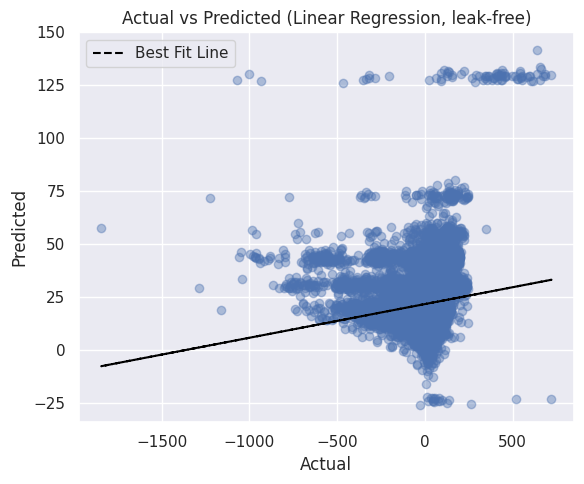

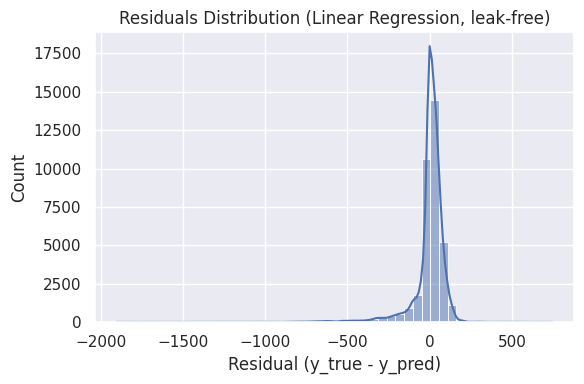

In [48]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_lin, alpha=0.4)
m, b = np.polyfit(y_test, y_pred_lin, 1)
plt.plot(y_test, m*y_test + b, color='black', linestyle='--', label='Best Fit Line')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted (Linear Regression, leak-free)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

residuals = y_test - y_pred_lin
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residuals Distribution (Linear Regression, leak-free)")
plt.xlabel("Residual (y_true - y_pred)")
plt.tight_layout()
plt.show()
